Folder `./notebooks/hpo/gridsearch/results/checkpoints` perlu dihapus jika terdapat perubahan pada dataset atau konfigurasi search space. Jika tidak, maka program akan load hasil dari run sebelumnya. Jadi konfigurasi terbaru hanya akan teraplikasikan pada konfigurasi yang belum atau belum selesai dijalankan.

- Sebelum program dijalankan, buat direktori `./dataset` pada root dir dan upload dataset
- Copy `.env.example` dan rename ke `.env`. Lalu ubah value dari variable `PROJECT_ROOT` menjadi absolute path ke project ini

In [1]:
!python -m pip install numpy pandas \
    qiskit-aer qiskit-algorithms qiskit-machine-learning qiskit-ibm-runtime \
    pylatexenc ucimlrepo \
    xgboost catboost seaborn libsvm-official \
    jinja2 \
    scikit-optimize


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv())
project_root = Path(os.environ["PROJECT_ROOT"])
print(f"Project root: {project_root}")

sys.path.append(os.path.abspath(project_root))

from utils.prepare_data import prepare_data

# import sys
# import os

# # Add project root (210226) to Python path
# sys.path.append(os.path.abspath("../../.."))

# from utils.prepare_data import prepare_data

Project root: c:\`Bioinformatics\quantum-gesang\codes


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [4]:
import warnings
from qiskit.transpiler import generate_preset_pass_manager
warnings.filterwarnings('ignore')

In [5]:
import sys
import importlib

def reload_package(package_name):
    modules_to_reload = [
        name for name in sys.modules
        if name.startswith(package_name)
    ]

    for name in sorted(modules_to_reload, reverse=True):
        importlib.reload(sys.modules[name])

# Usage
reload_package("model")
reload_package("utils")

In [6]:
import numpy as np

In [7]:
feature_cols = [
    "sepal length",
    "sepal width",
    "petal length",
    "petal width",
]
target_cols = "class"


## Utility

In [8]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
def plot_pca_variance(X, n_components, threshold=0.95):
  pca = PCA(n_components=n_components)
  pca.fit(X)

  cumvar = np.cumsum(pca.explained_variance_ratio_)
  n_optimal = np.argmax(cumvar >= threshold) + 1

  plt.figure(figsize=(8, 5))
  plt.plot(range(1, n_components + 1), cumvar, marker='o', color='blue')
  plt.axhline(y=threshold, color='gray', linestyle='--', linewidth=1)
  plt.xlabel('Number of Principal Components')
  plt.ylabel('Cumulative Explained Variance')
  plt.xticks(range(1, n_components + 1))
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  print(f'Optimal number of components to retain {threshold*100:.0f}% variance: {n_optimal}')

  return n_optimal

In [9]:
import time
from pathlib import Path
from datetime import datetime

all_best = []  # collects best_result from every model
_iter_t0 = None

# Logger setup
log_dir = Path("./results/logs/pqk")
log_dir.mkdir(parents=True, exist_ok=True)

_current_log_path = None

def setup_logger(name):
  """Panggil di awal tiap section. name contoh: 'svc_linear', 'xgb_gbtree'."""
  global _current_log_path
  _current_log_path = log_dir / f"quantum_{name}.log"
  # truncate file kalau sudah ada, biar tiap run fresh
  _current_log_path.write_text("")
  log(f"📝 Log: {_current_log_path}")
  log(f"🕒 Started: {datetime.now().isoformat(timespec='seconds')}")

def log(msg=""):
  """Print ke console dan append ke file log section aktif."""
  print(msg)
  if _current_log_path is not None:
    with open(_current_log_path, "a", encoding="utf-8") as f:
      f.write(str(msg) + "\n")


In [10]:
import pickle
from pathlib import Path

# Checkpoint dir — sama strukturnya kayak log_dir tapi pakai .pkl
ckpt_dir = Path("./results/checkpoints/scalability")  # ganti path sesuai notebook
ckpt_dir.mkdir(parents=True, exist_ok=True)

def load_checkpoint(name):
    """Load checkpoint kalau ada, return dict kosong kalau belum ada."""
    ckpt_path = ckpt_dir / f"quantum_{name}.pkl"
    if ckpt_path.exists():
        with open(ckpt_path, "rb") as f:
            data = pickle.load(f)
        log(f"♻️  Resumed checkpoint: {ckpt_path} ({len(data['done_configs'])} configs done)")
        return data, ckpt_path
    return {"done_configs": {}, "results": [], "best_result": None, "best_score": -np.inf}, ckpt_path

def save_checkpoint(ckpt_path, data):
    """Save progress atomically (tulis ke .tmp dulu, lalu rename)."""
    tmp = ckpt_path.with_suffix(".pkl.tmp")
    with open(tmp, "wb") as f:
        pickle.dump(data, f)
    tmp.replace(ckpt_path)  # atomic on most filesystems

## Scalability

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from model.quantum.qsvc import QSVCWrapper
from sklearn.decomposition import PCA
from itertools import product
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    average_precision_score, matthews_corrcoef,
    precision_score, recall_score
)
from ucimlrepo import fetch_ucirepo

# ── Load Iris dari UCI ML Repository (id=53) ──────────────────────────────────
_iris       = fetch_ucirepo(id=53)
_iris_X     = _iris.data.features
_iris_y     = _iris.data.targets
_iris_tgt   = _iris_y.columns[0]   # biasanya "class"
_iris_df    = _iris_X.copy()
_iris_df[target_cols] = _iris_y[_iris_tgt].values
print(f"Iris loaded — shape: {_iris_df.shape}  |  classes: {_iris_df[target_cols].unique().tolist()}")

# Stratified subsampling per kelas → dict of DataFrames
def _stratified_subsample(df, n_total, target_col, seed=42):
    """Ambil n_total sampel stratified by target_col (atau seluruh data kalau n_total >= len)."""
    if n_total >= len(df):
        return df.copy().reset_index(drop=True)
    frac = n_total / len(df)
    out = (df.groupby(target_col, group_keys=False)
             .apply(lambda g: g.sample(frac=frac, random_state=seed))
             .reset_index(drop=True))
    return out

# ── Konfigurasi scalability — sizes disesuaikan utk iris (150 total) ─────────
scalability_datasets = {
    50:  _stratified_subsample(_iris_df, 50,  target_cols),
    100: _stratified_subsample(_iris_df, 100, target_cols),
    150: _iris_df.copy().reset_index(drop=True),
}
scalability_kernels   = ['custom', 'full']
scalability_params    = {'C': 1, 'lambda_': 0.3}
scal_n_splits         = 5
scal_state            = 42


def _get_dataset(spec):
    """Spec bisa berupa DataFrame (iris in-memory) atau path string (CSV)."""
    if isinstance(spec, str):
        return pd.read_csv(spec)
    return spec.copy()


def run_scalability(QKERNEL: str, mode: str):
    """
    Evaluasi QSVC dengan kernel QKERNEL pada semua ukuran dataset.

    Returns:
        dict berisi kernel, mode, done_configs, results, best_result, best_score
        — siap dipakai langsung oleh `plot_scalability_comparison`.
    """
    setup_logger(f"scalability_qsvc_{QKERNEL}_{mode}")

    sizes      = list(scalability_datasets.keys())
    total_runs = len(sizes)

    log(f"🔬 Kernel: {QKERNEL}  | Mode: {mode}  |  Sizes: {sizes}  |  Folds: {scal_n_splits}")
    log( "   Scoring criterion: (AUROC + PRAUC + Accuracy) / 3")

    # ── Resume dari checkpoint ─────────────────────────────────────────────────
    ckpt, ckpt_path = load_checkpoint(f"scalability_qsvc_{QKERNEL}_{mode}")
    done_configs    = ckpt["done_configs"]
    results         = ckpt["results"]
    best_result     = ckpt["best_result"]
    best_score      = ckpt["best_score"]

    # ── Loop tiap ukuran dataset ──────────────────────────────────────────────
    for i, (size, ds_spec) in enumerate(scalability_datasets.items(), 1):
        tag = f"size={size} | kernel={QKERNEL}"

        if tag in done_configs:
            log(f"\n  ⏭️  [{i}/{total_runs}] {tag}  (skipped, already done)")
            continue

        log(f"\n  ▶ [{i}/{total_runs}] {tag}")
        _iter_t0 = time.perf_counter()

        # ── Load & prep dataset ────────────────────────────────────────────────
        df_s  = _get_dataset(ds_spec)
        X_s   = df_s[feature_cols]
        y_s   = LabelEncoder().fit_transform(df_s[target_cols])
        n_opt_s = plot_pca_variance(X_s, n_components=X_s.shape[1], threshold=0.95)
        log(f"   Shape: X={X_s.shape}  |  n_optimal={n_opt_s}")

        skf_s = StratifiedKFold(n_splits=scal_n_splits, shuffle=True,
                                random_state=scal_state)

        # ── Akumulasi per-fold ─────────────────────────────────────────────────
        accs, f1s, rocs, pras, precs, recs = [], [], [], [], [], []
        y_val_all, y_pred_all              = [], []

        for fold, (tr_idx, va_idx) in enumerate(skf_s.split(X_s, y_s), 1):
            X_tr, X_va = X_s.iloc[tr_idx], X_s.iloc[va_idx]
            y_tr, y_va = y_s[tr_idx],      y_s[va_idx]

            model = Pipeline([
                ('scaler', StandardScaler()),
                ('pca',    PCA(n_components=n_opt_s)),
                ('svc',    QSVCWrapper(
                    kernel=QKERNEL, mode=mode,
                    n_qubits=n_opt_s, n_features=n_opt_s,
                    random_state=scal_state,
                    decision_function_shape='ovr',
                    **scalability_params,
                )),
            ])
            model.fit(X_tr, y_tr)

            y_pred = model.predict(X_va)
            y_prob = model.predict_proba(X_va)

            y_val_all.extend(y_va)
            y_pred_all.extend(y_pred)

            acc  = accuracy_score(y_va, y_pred)
            f1   = f1_score(y_va, y_pred, average='weighted')
            roc  = roc_auc_score(y_va, y_prob, average='weighted', multi_class='ovr')
            pra  = average_precision_score(y_va, y_prob, average='weighted')
            prec = precision_score(y_va, y_pred, average='weighted', zero_division=0)
            rec  = recall_score(y_va, y_pred, average='weighted', zero_division=0)

            accs.append(acc);  f1s.append(f1)
            rocs.append(roc);  pras.append(pra)
            precs.append(prec); recs.append(rec)

            log(f"    F{fold} → Acc={acc:.4f} | Prec={prec:.4f} | "
                f"Rec={rec:.4f} | F1={f1:.4f} | "
                f"AUROC={roc:.4f} | PRAUC={pra:.4f}")

            results.append({
                "tag":       tag,
                "size":      size,
                "kernel":    QKERNEL,
                "fold":      fold,
                "accuracy":  acc,
                "precision": prec,
                "recall":    rec,
                "F1":        f1,
                "auroc":     roc,
                "prauc":     pra,
            })

        # ── Agregat ────────────────────────────────────────────────────────────
        acc_mean,  acc_std  = np.mean(accs),  np.std(accs)
        prec_mean, prec_std = np.mean(precs), np.std(precs)
        rec_mean,  rec_std  = np.mean(recs),  np.std(recs)
        f1_mean,   f1_std   = np.mean(f1s),   np.std(f1s)
        roc_mean,  roc_std  = np.mean(rocs),  np.std(rocs)
        pra_mean,  pra_std  = np.mean(pras),  np.std(pras)
        mcc                 = matthews_corrcoef(y_val_all, y_pred_all)
        composite           = (roc_mean + pra_mean + acc_mean) / 3
        iter_time           = time.perf_counter() - _iter_t0

        log(
            f"  ✅  Acc:{acc_mean:.4f}±{acc_std:.4f} | "
            f"Precision:{prec_mean:.4f}±{prec_std:.4f} | "
            f"Recall:{rec_mean:.4f}±{rec_std:.4f} | "
            f"F1:{f1_mean:.4f}±{f1_std:.4f} | "
            f"AUROC:{roc_mean:.4f}±{roc_std:.4f} | "
            f"PRAUC:{pra_mean:.4f}±{pra_std:.4f} | "
            f"MCC:{mcc:.4f} | "
            f"Composite:{composite:.4f} | "
            f"Time:{iter_time:.1f}s"
        )

        # ── Update best ────────────────────────────────────────────────────────
        if composite > best_score:
            best_score  = composite
            best_result = {
                'tag':            tag,
                'composite':      composite,
                'roc':            f"{roc_mean:.4f}±{roc_std:.4f}",
                'pra':            f"{pra_mean:.4f}±{pra_std:.4f}",
                'acc':            f"{acc_mean:.4f}±{acc_std:.4f}",
                'f1':             f"{f1_mean:.4f}±{f1_std:.4f}",
                'prec':           f"{prec_mean:.4f}±{prec_std:.4f}",
                'rec':            f"{rec_mean:.4f}±{rec_std:.4f}",
                'size':           size,
                'execution_time': iter_time,
            }

        # ── Simpan ke checkpoint ───────────────────────────────────────────────
        done_configs[tag] = {
            "composite": composite,
            "size":      size,
            "kernel":    QKERNEL,
            "acc_mean":  acc_mean,   "acc_std":  acc_std,
            "prec_mean": prec_mean,  "prec_std": prec_std,
            "rec_mean":  rec_mean,   "rec_std":  rec_std,
            "f1_mean":   f1_mean,    "f1_std":   f1_std,
            "roc_mean":  roc_mean,   "roc_std":  roc_std,
            "pra_mean":  pra_mean,   "pra_std":  pra_std,
            "mcc":       mcc,
            "exec_time": iter_time,
            "n_optimal": n_opt_s,
        }
        save_checkpoint(ckpt_path, {
            "done_configs": done_configs,
            "results":      results,
            "best_result":  best_result,
            "best_score":   best_score,
        })

    # ── Ringkasan akhir ────────────────────────────────────────────────────────
    if best_result is not None:
        log(f"\n🏆 Best config : {best_result['tag']}")
        log(
            f"   Composite   : {best_result['composite']:.4f} "
            f"(AUROC={best_result['roc']} | "
            f"PRAUC={best_result['pra']} | "
            f"Acc={best_result['acc']} | "
            f"Prec={best_result['prec']} | "
            f"Rec={best_result['rec']})"
        )

    return {
        "kernel":       QKERNEL,
        "mode":         mode,
        "done_configs": done_configs,
        "results":      results,
        "best_result":  best_result,
        "best_score":   best_score,
    }


Iris loaded — shape: (150, 5)  |  classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


In [12]:
def plot_scalability_comparison(*runs, metrics=None, save_path=None):
    """
    Plot skalabilitas untuk N hasil `run_scalability` sekaligus dalam 1 figure.

    Usage:
        custom_pqk = run_scalability('custom', 'pqk')
        full_pqk   = run_scalability('full',   'pqk')
        custom_fsk = run_scalability('custom', 'fsk')
        plot_scalability_comparison(custom_pqk, full_pqk, custom_fsk)

    Args:
        *runs    : N hasil dari `run_scalability` (dict berisi
                   'kernel', 'mode', 'done_configs').
        metrics  : list metrik yang diplot (default: 6 metrik standar).
        save_path: kalau diisi, simpan figure ke path tsb.
    """
    if not runs:
        raise ValueError("plot_scalability_comparison butuh minimal 1 hasil run.")

    if metrics is None:
        metrics = ['acc_mean', 'f1_mean', 'roc_mean', 'pra_mean', 'prec_mean', 'rec_mean']

    metric_labels = {
        'acc_mean':  'Accuracy',
        'f1_mean':   'F1 Score',
        'roc_mean':  'AUROC',
        'pra_mean':  'PRAUC',
        'prec_mean': 'Precision',
        'rec_mean':  'Recall',
    }
    std_keys = {k: k.replace('_mean', '_std') for k in metrics}

    # style preset utk kombinasi umum; di luar itu pakai fallback palette
    preset_styles = {
        ('custom', 'pqk'): {'color': '#5B4FCF', 'marker': 'o', 'linestyle': '-'},
        ('full',   'pqk'): {'color': '#1D9E75', 'marker': 's', 'linestyle': '-'},
        ('custom', 'fsk'): {'color': '#E67E22', 'marker': '^', 'linestyle': '--'},
        ('full',   'fsk'): {'color': '#C0392B', 'marker': 'D', 'linestyle': '--'},
    }
    fallback_palette = ['#3498DB', '#9B59B6', '#16A085', '#F39C12',
                        '#7F8C8D', '#2C3E50', '#E84393', '#00B894']
    fallback_markers = ['o', 's', '^', 'D', 'v', 'P', 'X', '*']

    def style_for(kernel, mode, idx):
        if (kernel, mode) in preset_styles:
            return preset_styles[(kernel, mode)]
        return {
            'color':     fallback_palette[idx % len(fallback_palette)],
            'marker':    fallback_markers[idx % len(fallback_markers)],
            'linestyle': '-' if mode == 'pqk' else '--',
        }

    sizes    = sorted(scalability_datasets.keys())
    x        = np.arange(len(sizes))
    x_labels = [f"{s//1000}k" if s >= 1000 else str(s) for s in sizes]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_metrics = len(metrics)
    ncols     = 3
    nrows     = (n_metrics + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.5 * ncols, 4 * nrows),
                             constrained_layout=True)
    axes = np.array(axes).flatten()

    for ax, metric in zip(axes, metrics):
        for idx, run in enumerate(runs):
            kernel = run["kernel"]
            mode   = run["mode"]
            rows   = {rec["size"]: rec for rec in run["done_configs"].values()}

            ys   = np.array([rows[s][metric]           if s in rows else np.nan for s in sizes])
            errs = np.array([rows[s][std_keys[metric]] if s in rows else np.nan for s in sizes])

            style = style_for(kernel, mode, idx)

            ax.plot(x, ys,
                    label=f"QSVC-{kernel.upper()} ({mode.upper()})",
                    color=style['color'],
                    marker=style['marker'],
                    linestyle=style['linestyle'],
                    markersize=6,
                    linewidth=1.8)
            ax.fill_between(x, ys - errs, ys + errs,
                            color=style['color'], alpha=0.10)

        ax.set_title(metric_labels.get(metric, metric), fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=9)
        ax.set_xlabel("Jumlah sampel", fontsize=10)
        ax.set_ylabel("Mean ± Std", fontsize=10)
        ax.set_ylim(0, 1.05)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=8)

    for ax in axes[n_metrics:]:
        ax.set_visible(False)

    fig.suptitle(
        f"Skalabilitas QSVC  "
        f"(C={scalability_params['C']}, λ={scalability_params['lambda_']})",
        fontsize=13, fontweight='bold'
    )

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        log(f"📊 Plot disimpan → {save_path}")

    plt.show()
    # return fig

In [13]:
# # custom_pqk = run_scalability('custom_full', 'pqk')
# full_pqk   = run_scalability('full',   'pqk')
# # linear_pqk = run_scalability('custom_linear', 'pqk')
# # circular_pqk = run_scalability('custom_circular', 'pqk')
# # custom_fsk = run_scalability('custom_full', 'fsk')
# # full_fsk   = run_scalability('full',   'fsk')


# plot_scalability_comparison(full_pqk)

## Overfit / Underfit & Barren Plateau Diagnostic

Tiga diagnostik untuk membantu desain sirkuit kuantum kustom:

1. **Kernel matrix diagnostic** — apakah Gram matrix `K(X,X)` overfit (≈identity / memorisasi), underfit (entry collapse / KTA rendah), atau sehat (block-class structure jelas).
2. **Barren plateau diagnostic** — sweep `n_qubits` dan cek scaling `Var(K_off_diag)`. Penurunan eksponensial ⇒ kernel concentration / BP.
3. **Model overfit/underfit** — learning curve standard untuk QSVC pipeline.

Catatan: ganti `KERNEL_KIND`, `MODE`, `LAMBDA_`, `DATASET_SIZE` di tiap cell sesuai konfigurasi sirkuit yang sedang di-tune.


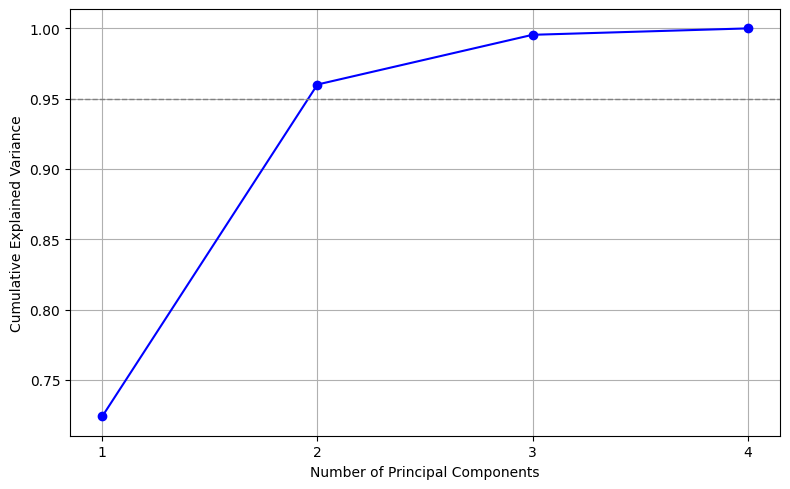

Optimal number of components to retain 95% variance: 2
Train: (105, 2)  |  Val: (45, 2)  |  n_qubits=2
Computing K_tr (105×105) ...
Computing K_va×tr (45×105) ...
Computing K_va (45×45) untuk val KTA ...
Computing eigenvalues (eigvalsh) — ini lambat untuk N besar ...


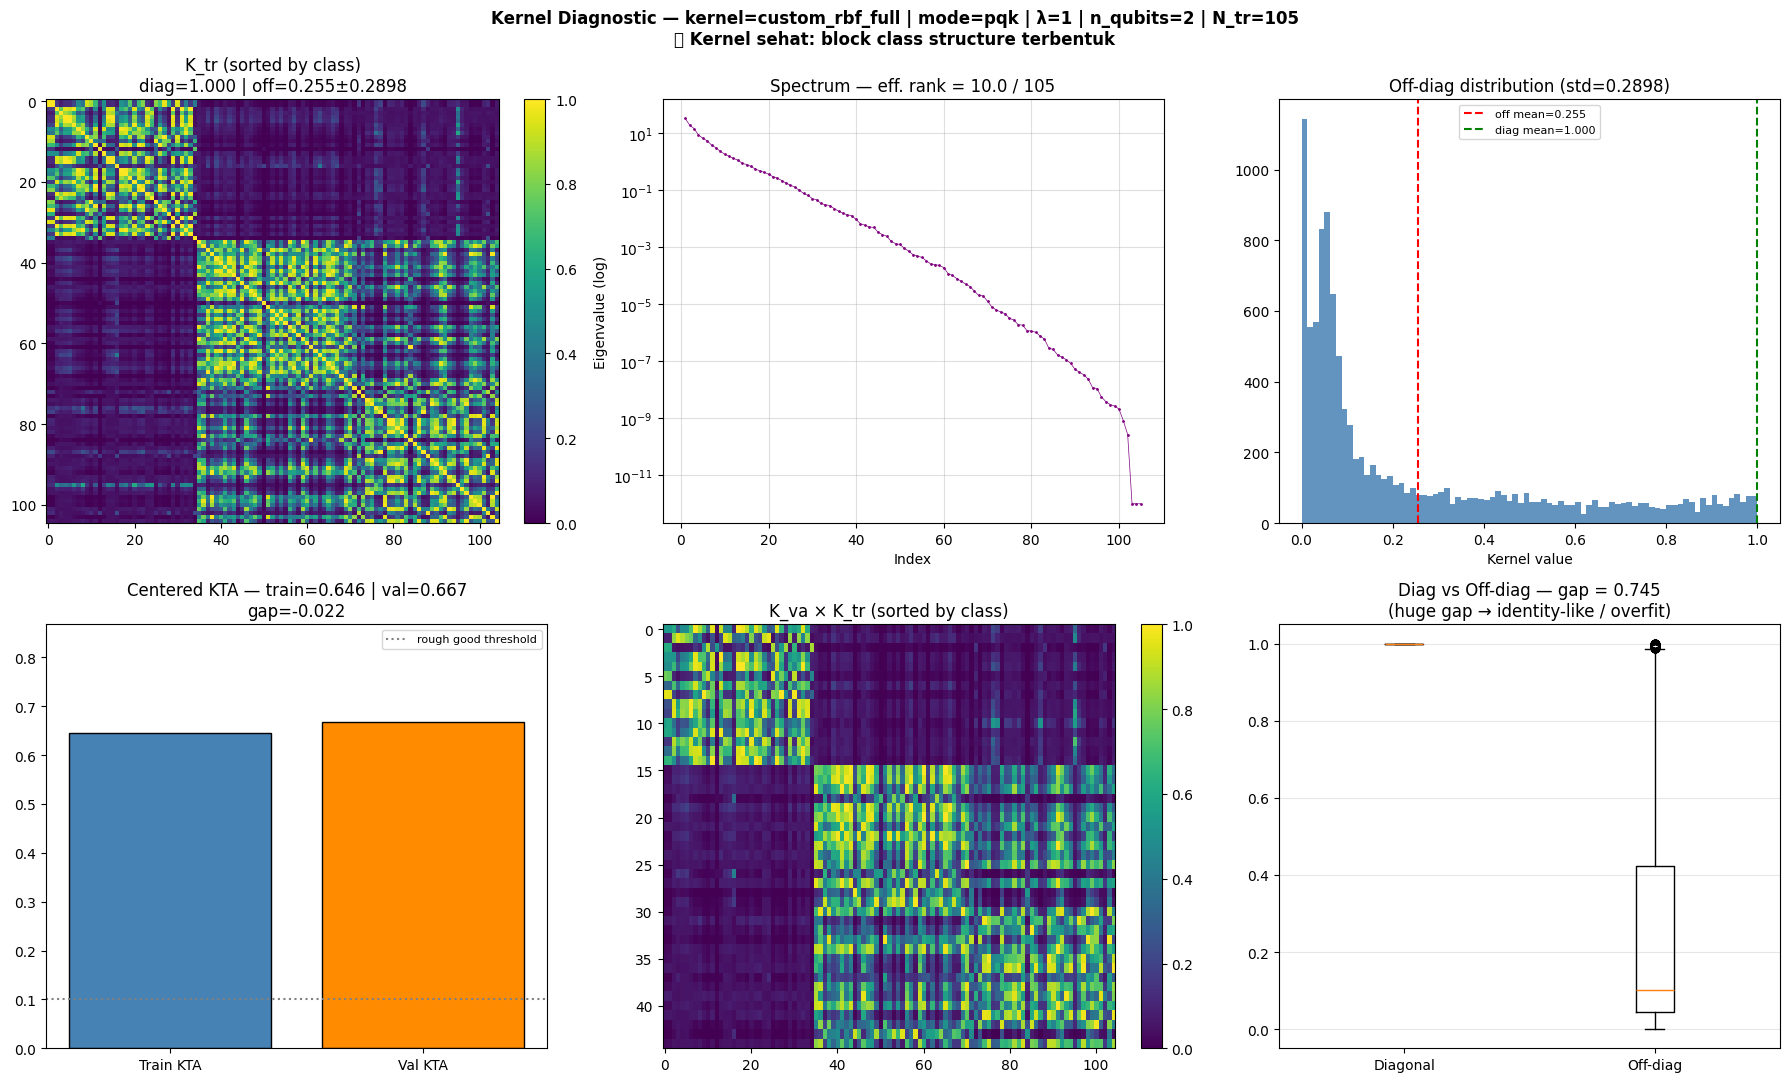


✅ Kernel sehat: block class structure terbentuk
diag_mean=1.0000 | off_mean=0.2552 | off_std=0.2898
train_kta=0.6456 | val_kta=0.6673
eff_rank=10.05 / 105


In [14]:
# ── 1. Kernel matrix overfit/underfit diagnostic ─────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from model.quantum.estimator import QuantumKernelEstimator

# Konfigurasi — ganti sesuai eksperimen
KERNEL_KIND   = "custom_rbf_full"   # 'full' | 'linear' | 'circular' | 'custom_full' | 'custom_linear' | 'custom_circular'
MODE          = "pqk"           # 'fsk' | 'fqk' | 'pqk'
LAMBDA_       = 1
DATASET_SIZE  = 150             # iris total = 150

# ── Data — pakai SEMUA sampel dataset ──────────────────────────────────────────
_df_kd = scalability_datasets[DATASET_SIZE].copy()
X_kd   = _df_kd[feature_cols].values
y_kd   = LabelEncoder().fit_transform(_df_kd[target_cols])

X_tr_kd, X_va_kd, y_tr_kd, y_va_kd = train_test_split(
    X_kd, y_kd, test_size=0.3, stratify=y_kd, random_state=42,
)

scaler = StandardScaler().fit(X_tr_kd)
X_tr_kd, X_va_kd = scaler.transform(X_tr_kd), scaler.transform(X_va_kd)
n_opt_kd = plot_pca_variance(pd.DataFrame(X_tr_kd), n_components=X_tr_kd.shape[1], threshold=0.95)
pca = PCA(n_components=n_opt_kd).fit(X_tr_kd)
X_tr_kd, X_va_kd = pca.transform(X_tr_kd), pca.transform(X_va_kd)

print(f"Train: {X_tr_kd.shape}  |  Val: {X_va_kd.shape}  |  n_qubits={n_opt_kd}")

# ── Build kernel & compute Gram matrices ───────────────────────────────────────
est = QuantumKernelEstimator(kernel=KERNEL_KIND, n_qubits=n_opt_kd, lambda_=LAMBDA_)
est.build_quantum_kernel(n_features=n_opt_kd, mode=MODE)

print(f"Computing K_tr ({len(X_tr_kd)}×{len(X_tr_kd)}) ...")
K_tr = est.compute_kernel_matrix(X_tr_kd)
print(f"Computing K_va×tr ({len(X_va_kd)}×{len(X_tr_kd)}) ...")
K_vt = est.compute_kernel_matrix(X_va_kd, X_tr_kd)
print(f"Computing K_va ({len(X_va_kd)}×{len(X_va_kd)}) untuk val KTA ...")
K_va = est.compute_kernel_matrix(X_va_kd)

# ── Metrics ────────────────────────────────────────────────────────────────────
def centered_kta(K, y):
    """Centered kernel-target alignment for multi-class (one-hot ideal kernel)."""
    n = len(y)
    H = np.eye(n) - np.ones((n, n)) / n
    Yoh = OneHotEncoder(sparse_output=False).fit_transform(y.reshape(-1, 1))
    Y_ideal = Yoh @ Yoh.T
    Kc, Yc = H @ K @ H, H @ Y_ideal @ H
    num = np.sum(Kc * Yc)
    den = np.linalg.norm(Kc, "fro") * np.linalg.norm(Yc, "fro") + 1e-12
    return num / den

diag_K     = np.diag(K_tr)
off_mask   = ~np.eye(len(K_tr), dtype=bool)
off_K      = K_tr[off_mask]
diag_mean  = diag_K.mean()
off_mean   = off_K.mean()
off_std    = off_K.std()

print("Computing eigenvalues (eigvalsh) — ini lambat untuk N besar ...")
eigvals = np.sort(np.linalg.eigvalsh(K_tr))[::-1]
ev_pos  = eigvals[eigvals > 1e-10]
p       = ev_pos / ev_pos.sum()
eff_rank = float(np.exp(-np.sum(p * np.log(p))))

train_kta = centered_kta(K_tr, y_tr_kd)
val_kta   = centered_kta(K_va, y_va_kd)

# ── Heuristic diagnosis ────────────────────────────────────────────────────────
gap = diag_mean - off_mean
if gap > 0.85 and off_std < 0.05:
    verdict = "⚠️  OVERFIT-LIKE: kernel ≈ identity (memorisasi, off-diag tipis)"
elif off_std < 0.005:
    verdict = "⚠️  CONCENTRATED: off-diag collapse → kandidat barren plateau (cek cell BP)"
elif train_kta < 0.05:
    verdict = "⚠️  UNDERFIT: KTA rendah, kernel tidak align dengan label"
elif (train_kta - val_kta) > 0.2:
    verdict = "⚠️  OVERFIT-KTA: train KTA jauh di atas val KTA"
else:
    verdict = "✅ Kernel sehat: block class structure terbentuk"

# ── Plot ───────────────────────────────────────────────────────────────────────
order_tr = np.argsort(y_tr_kd)
order_va = np.argsort(y_va_kd)
K_tr_sorted = K_tr[order_tr][:, order_tr]
K_vt_sorted = K_vt[order_va][:, order_tr]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# (0,0) K_tr heatmap, sorted by class
im0 = axes[0, 0].imshow(K_tr_sorted, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axes[0, 0].set_title(f"K_tr (sorted by class)\ndiag={diag_mean:.3f} | off={off_mean:.3f}±{off_std:.4f}")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

# (0,1) Eigenvalue spectrum (log)
axes[0, 1].semilogy(np.arange(1, len(eigvals) + 1), np.clip(eigvals, 1e-12, None),
                    marker=".", color="purple", markersize=2, linewidth=0.5)
axes[0, 1].set_xlabel("Index")
axes[0, 1].set_ylabel("Eigenvalue (log)")
axes[0, 1].set_title(f"Spectrum — eff. rank = {eff_rank:.1f} / {len(K_tr)}")
axes[0, 1].grid(True, alpha=0.4)

# (0,2) Off-diagonal histogram
axes[0, 2].hist(off_K, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
axes[0, 2].axvline(off_mean, color="red", linestyle="--", label=f"off mean={off_mean:.3f}")
axes[0, 2].axvline(diag_mean, color="green", linestyle="--", label=f"diag mean={diag_mean:.3f}")
axes[0, 2].set_xlabel("Kernel value")
axes[0, 2].set_title(f"Off-diag distribution (std={off_std:.4f})")
axes[0, 2].legend(fontsize=8)

# (1,0) KTA bars
axes[1, 0].bar(["Train KTA", "Val KTA"], [train_kta, val_kta],
               color=["steelblue", "darkorange"], edgecolor="black")
axes[1, 0].axhline(0.1, color="grey", linestyle=":", label="rough good threshold")
axes[1, 0].set_ylim(0, max(0.6, max(train_kta, val_kta) * 1.3))
axes[1, 0].set_title(f"Centered KTA — train={train_kta:.3f} | val={val_kta:.3f}\ngap={train_kta-val_kta:+.3f}")
axes[1, 0].legend(fontsize=8)

# (1,1) K_va × tr heatmap
im1 = axes[1, 1].imshow(K_vt_sorted, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axes[1, 1].set_title("K_va × K_tr (sorted by class)")
plt.colorbar(im1, ax=axes[1, 1], fraction=0.046)

# (1,2) Diag vs off-diag boxplot
axes[1, 2].boxplot([diag_K, off_K], tick_labels=["Diagonal", "Off-diag"])
axes[1, 2].set_title(f"Diag vs Off-diag — gap = {gap:.3f}\n(huge gap → identity-like / overfit)")
axes[1, 2].grid(True, axis="y", alpha=0.3)

fig.suptitle(
    f"Kernel Diagnostic — kernel={KERNEL_KIND} | mode={MODE} | λ={LAMBDA_} | n_qubits={n_opt_kd} | N_tr={len(X_tr_kd)}\n{verdict}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\n{verdict}")
print(f"diag_mean={diag_mean:.4f} | off_mean={off_mean:.4f} | off_std={off_std:.4f}")
print(f"train_kta={train_kta:.4f} | val_kta={val_kta:.4f}")
print(f"eff_rank={eff_rank:.2f} / {len(K_tr)}")


BP sweep menggunakan N = 150 samples (full dataset)
  • kernel=custom_full  n_qubits=2  N=150 ... var=7.707e-02  mean=0.196
  • kernel=custom_full  n_qubits=3  N=150 ... var=5.848e-02  mean=0.163
  • kernel=custom_full  n_qubits=4  N=150 ... var=5.704e-02  mean=0.163
  • kernel=custom_linear  n_qubits=2  N=150 ... var=7.707e-02  mean=0.196
  • kernel=custom_linear  n_qubits=3  N=150 ... var=5.805e-02  mean=0.161
  • kernel=custom_linear  n_qubits=4  N=150 ... var=5.546e-02  mean=0.157
  • kernel=custom_circular  n_qubits=2  N=150 ... var=7.833e-02  mean=0.204
  • kernel=custom_circular  n_qubits=3  N=150 ... var=5.848e-02  mean=0.163
  • kernel=custom_circular  n_qubits=4  N=150 ... var=5.570e-02  mean=0.159
  • kernel=custom_rbf_full  n_qubits=2  N=150 ... var=7.766e-02  mean=0.199
  • kernel=custom_rbf_full  n_qubits=3  N=150 ... var=5.979e-02  mean=0.168
  • kernel=custom_rbf_full  n_qubits=4  N=150 ... var=5.906e-02  mean=0.172
  • kernel=custom_rbf_linear  n_qubits=2  N=150 ... va

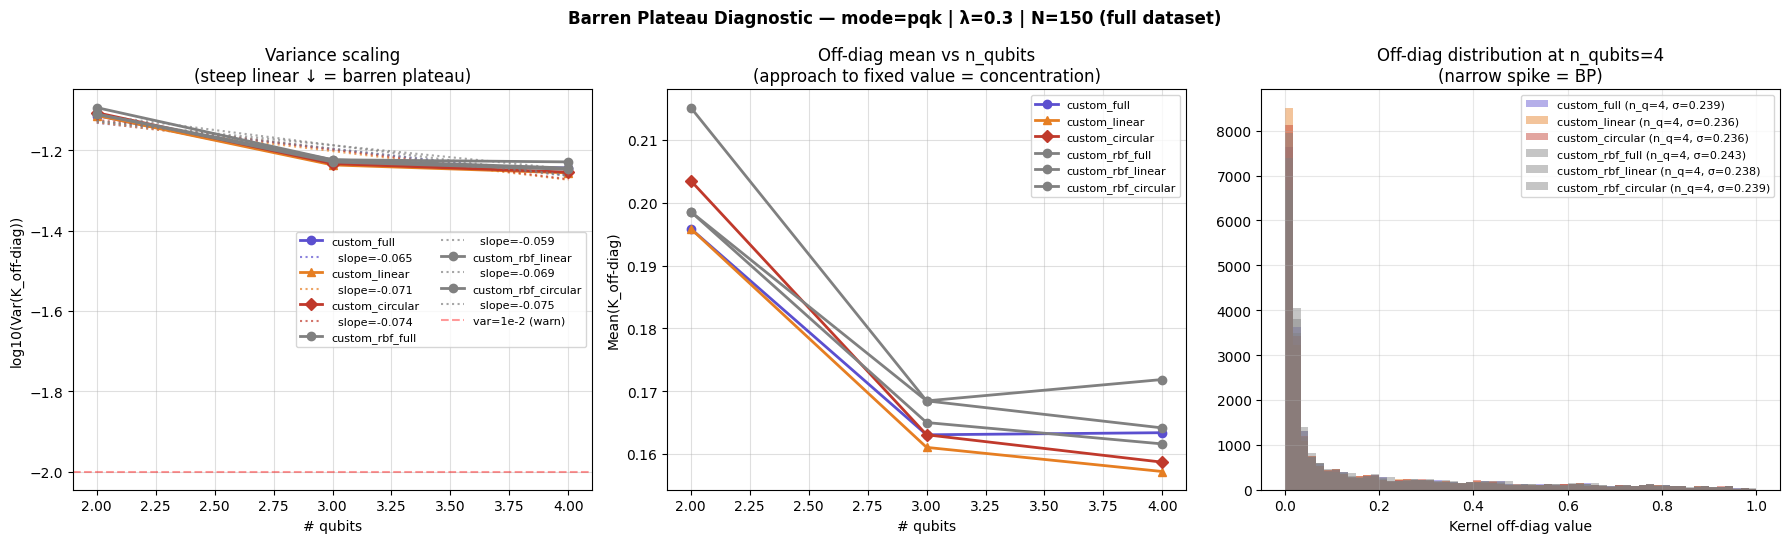


Slope log10(Var) vs n_qubits — semakin negatif semakin mengarah ke BP:
  custom_full         slope = -0.065   var(n_max) = 5.704e-02   → ✅ sehat
  custom_linear       slope = -0.071   var(n_max) = 5.546e-02   → ✅ sehat
  custom_circular     slope = -0.074   var(n_max) = 5.570e-02   → ✅ sehat
  custom_rbf_full     slope = -0.059   var(n_max) = 5.906e-02   → ✅ sehat
  custom_rbf_linear   slope = -0.069   var(n_max) = 5.660e-02   → ✅ sehat
  custom_rbf_circular  slope = -0.075   var(n_max) = 5.702e-02   → ✅ sehat


In [15]:
# ── 2. Barren plateau diagnostic ─────────────────────────────────────────────
# Idea: sweep n_qubits, hitung Var(K_off_diag). Untuk circuit dengan BP,
# var jatuh ~ exp(-c·n_qubits), jadi log10(var) vs n_qubits = garis lurus turun.
# Healthy circuit: var tetap O(1).
#
# Iris: 150 sampel, 4 feature → BP sweep relatif cepat.

from model.quantum.estimator import QuantumKernelEstimator

BP_KERNELS    = [
    "custom_full", "custom_linear", "custom_circular",
    "custom_rbf_full", "custom_rbf_linear", "custom_rbf_circular",
]  # bandingkan
BP_MODE       = "pqk"
BP_LAMBDA     = 0.3
BP_NQUBITS    = [2, 3, 4]           # iris hanya 4 feature → batas wajar
BP_DATASET    = 150                 # iris total

# ── Data — pakai SEMUA sampel ──────────────────────────────────────────────────
_df_bp    = scalability_datasets[BP_DATASET].copy()
X_bp_full = _df_bp[feature_cols].values
X_bp_raw  = StandardScaler().fit_transform(X_bp_full)
print(f"BP sweep menggunakan N = {len(X_bp_raw)} samples (full dataset)")

# ── Sweep ──────────────────────────────────────────────────────────────────────
def kernel_offdiag_stats(kernel_kind, mode, n_qubits, X_raw, lambda_):
    # PCA ke n_qubits dim. Kalau dataset feature < n_qubits, pad nol.
    if X_raw.shape[1] >= n_qubits:
        Xq = PCA(n_components=n_qubits, random_state=42).fit_transform(X_raw)
    else:
        Xq = np.hstack([X_raw, np.zeros((len(X_raw), n_qubits - X_raw.shape[1]))])
    est = QuantumKernelEstimator(kernel=kernel_kind, n_qubits=n_qubits, lambda_=lambda_)
    est.build_quantum_kernel(n_features=n_qubits, mode=mode)
    K = est.compute_kernel_matrix(Xq)
    off = K[~np.eye(len(K), dtype=bool)]
    return {"mean": off.mean(), "var": off.var(), "std": off.std(), "K": K}

bp_results = {k: [] for k in BP_KERNELS}
for k in BP_KERNELS:
    for nq in BP_NQUBITS:
        print(f"  • kernel={k}  n_qubits={nq}  N={len(X_bp_raw)} ...", end=" ", flush=True)
        s = kernel_offdiag_stats(k, BP_MODE, nq, X_bp_raw, BP_LAMBDA)
        # buang full K supaya tidak boros memori (cuma simpan stats + sample utk hist)
        rng = np.random.default_rng(0)
        flat_off = s["K"][~np.eye(len(s["K"]), dtype=bool)]
        sample_off = rng.choice(flat_off, size=min(len(flat_off), 50_000), replace=False)
        bp_results[k].append((nq, {**{kk: vv for kk, vv in s.items() if kk != "K"},
                                   "off_sample": sample_off}))
        print(f"var={s['var']:.3e}  mean={s['mean']:.3f}")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

palette  = {"full": "#1D9E75", "custom_full": "#5B4FCF",
            "custom_linear": "#E67E22", "custom_circular": "#C0392B"}
markers  = {"full": "s", "custom_full": "o",
            "custom_linear": "^", "custom_circular": "D"}

# (0) log10(Var) vs n_qubits — slope < ~-0.3 = BP red flag
for k, runs in bp_results.items():
    nqs = [r[0] for r in runs]
    vs  = [r[1]["var"] for r in runs]
    col = palette.get(k, "grey")
    mk  = markers.get(k, "o")
    axes[0].plot(nqs, np.log10(np.clip(vs, 1e-20, None)),
                 marker=mk, color=col, linewidth=2, label=k)
    if len(nqs) >= 2:
        coef = np.polyfit(nqs, np.log10(np.clip(vs, 1e-20, None)), 1)
        axes[0].plot(nqs, np.polyval(coef, nqs),
                     linestyle=":", color=col, alpha=0.7,
                     label=f"  slope={coef[0]:+.3f}")
axes[0].axhline(-2, color="red", linestyle="--", alpha=0.4, label="var=1e-2 (warn)")
axes[0].set_xlabel("# qubits")
axes[0].set_ylabel("log10(Var(K_off-diag))")
axes[0].set_title("Variance scaling\n(steep linear ↓ = barren plateau)")
axes[0].grid(True, alpha=0.4)
axes[0].legend(fontsize=8, ncol=2)

# (1) Mean vs n_qubits — kalau plateau ke konstan → kernel concentration
for k, runs in bp_results.items():
    nqs = [r[0] for r in runs]
    ms  = [r[1]["mean"] for r in runs]
    axes[1].plot(nqs, ms, marker=markers.get(k, "o"),
                 color=palette.get(k, "grey"), linewidth=2, label=k)
axes[1].set_xlabel("# qubits")
axes[1].set_ylabel("Mean(K_off-diag)")
axes[1].set_title("Off-diag mean vs n_qubits\n(approach to fixed value = concentration)")
axes[1].grid(True, alpha=0.4)
axes[1].legend(fontsize=8)

# (2) Distribusi off-diag — pakai n_qubits terbesar untuk tiap kernel
for k, runs in bp_results.items():
    nq, s = runs[-1]
    axes[2].hist(s["off_sample"], bins=60, alpha=0.45,
                 color=palette.get(k, "grey"),
                 label=f"{k} (n_q={nq}, σ={s['std']:.3f})")
axes[2].set_xlabel("Kernel off-diag value")
axes[2].set_title(f"Off-diag distribution at n_qubits={BP_NQUBITS[-1]}\n(narrow spike = BP)")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

fig.suptitle(f"Barren Plateau Diagnostic — mode={BP_MODE} | λ={BP_LAMBDA} | N={len(X_bp_raw)} (full dataset)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Verdict ────────────────────────────────────────────────────────────────────
print("\nSlope log10(Var) vs n_qubits — semakin negatif semakin mengarah ke BP:")
for k, runs in bp_results.items():
    nqs = [r[0] for r in runs]
    vs  = [r[1]["var"] for r in runs]
    slope = np.polyfit(nqs, np.log10(np.clip(vs, 1e-20, None)), 1)[0]
    last_var = vs[-1]
    tag = ("⚠️  BP-like" if slope < -0.3 and last_var < 1e-2 else
           "🟡 mild concentration" if slope < -0.15 else
           "✅ sehat")
    print(f"  {k:<18}  slope = {slope:+.3f}   var(n_max) = {last_var:.3e}   → {tag}")


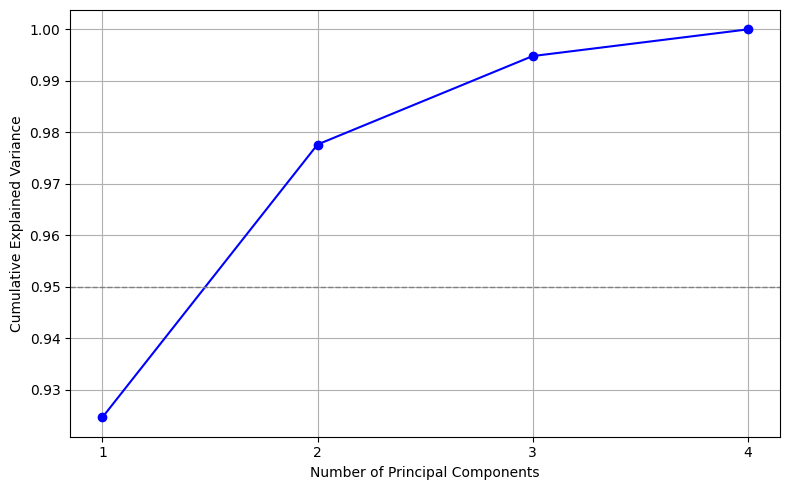

Optimal number of components to retain 95% variance: 2
Dataset: (150, 4)  |  n_qubits=2
Computing learning curve — kernel=custom_rbf_full, mode=pqk, sizes=[0.2 0.4 0.6 0.8 1. ] ...


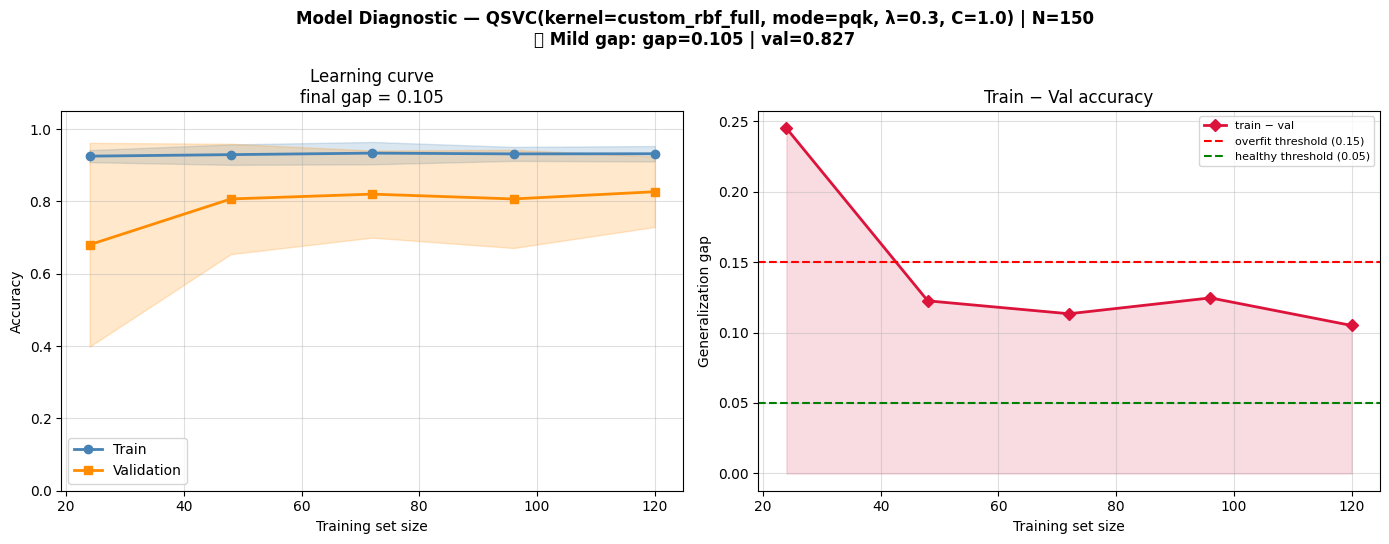


🟡 Mild gap: gap=0.105 | val=0.827
Train acc (final): 0.9317 ± 0.0213
Val   acc (final): 0.8267 ± 0.0975


In [16]:
# ── 3. Model overfit/underfit diagnostic (learning curve) ────────────────────
# Iris: 150 sampel. learning_curve ringan — bisa pakai CV besar dan banyak train sizes.

from sklearn.model_selection import learning_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from model.quantum.qsvc import QSVCWrapper

# Konfigurasi — sinkron sama cell kernel diagnostic
M_KERNEL_KIND  = "custom_rbf_full"
M_MODE         = "pqk"
M_LAMBDA       = 0.3
M_C            = 1.0
M_DATASET      = 150     # iris total
M_CV           = 5       # CV folds
M_TRAIN_SIZES  = np.linspace(0.2, 1.0, 5)

# ── Data — pakai SEMUA sampel ──────────────────────────────────────────────────
_df_m = scalability_datasets[M_DATASET].copy()
X_m   = _df_m[feature_cols].values
y_m   = LabelEncoder().fit_transform(_df_m[target_cols])
n_opt_m = plot_pca_variance(pd.DataFrame(X_m), n_components=X_m.shape[1], threshold=0.95)
print(f"Dataset: {X_m.shape}  |  n_qubits={n_opt_m}")

def make_pipe():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("pca",    PCA(n_components=n_opt_m)),
        ("qsvc",   QSVCWrapper(
            kernel=M_KERNEL_KIND, mode=M_MODE,
            n_qubits=n_opt_m, n_features=n_opt_m,
            lambda_=M_LAMBDA, C=M_C,
            random_state=42, decision_function_shape="ovr",
        )),
    ])

print(f"Computing learning curve — kernel={M_KERNEL_KIND}, mode={M_MODE}, sizes={M_TRAIN_SIZES} ...")
train_sizes_abs, train_scores, val_scores = learning_curve(
    make_pipe(), X_m, y_m,
    train_sizes=M_TRAIN_SIZES, cv=M_CV,
    scoring="accuracy", n_jobs=1, shuffle=True, random_state=42,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean,   val_std   = val_scores.mean(axis=1),   val_scores.std(axis=1)
final_gap = train_mean[-1] - val_mean[-1]

if final_gap > 0.15:
    verdict_m = f"⚠️  OVERFIT: train−val gap = {final_gap:.3f} > 0.15"
elif val_mean[-1] < 0.6:
    verdict_m = f"⚠️  UNDERFIT: val accuracy = {val_mean[-1]:.3f} < 0.6"
elif final_gap < 0.05 and val_mean[-1] > 0.8:
    verdict_m = f"✅ Well-fit: gap={final_gap:.3f} | val={val_mean[-1]:.3f}"
else:
    verdict_m = f"🟡 Mild gap: gap={final_gap:.3f} | val={val_mean[-1]:.3f}"

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (0) Learning curve
axes[0].plot(train_sizes_abs, train_mean, "o-", color="steelblue", linewidth=2, label="Train")
axes[0].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std,
                     alpha=0.2, color="steelblue")
axes[0].plot(train_sizes_abs, val_mean, "s-", color="darkorange", linewidth=2, label="Validation")
axes[0].fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std,
                     alpha=0.2, color="darkorange")
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("Accuracy")
axes[0].set_title(f"Learning curve\nfinal gap = {final_gap:.3f}")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.4)
axes[0].legend()

# (1) Generalization gap
gap_curve = train_mean - val_mean
axes[1].plot(train_sizes_abs, gap_curve, "D-", color="crimson", linewidth=2, label="train − val")
axes[1].fill_between(train_sizes_abs, gap_curve, 0, alpha=0.15, color="crimson")
axes[1].axhline(0.15, color="red", linestyle="--", label="overfit threshold (0.15)")
axes[1].axhline(0.05, color="green", linestyle="--", label="healthy threshold (0.05)")
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Generalization gap")
axes[1].set_title("Train − Val accuracy")
axes[1].grid(True, alpha=0.4)
axes[1].legend(fontsize=8)

fig.suptitle(
    f"Model Diagnostic — QSVC(kernel={M_KERNEL_KIND}, mode={M_MODE}, λ={M_LAMBDA}, C={M_C}) | N={len(X_m)}\n{verdict_m}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
plt.show()

print(f"\n{verdict_m}")
print(f"Train acc (final): {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Val   acc (final): {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
